# Biodiversity
## Introduction
In this analysis we'll be diving into National Parks Service data to investigate conservation statuses of endangered species and if there are any patterns or themes to the types of species that become endangered.<br>

## Scope
The goal of this project is to answer the following questions:
- What is the data?
- What is the distribution of species across parks?
- What is the distribution of conservation statuses across species?
- How are conservation efforts among parks?

In [1]:
# Importing used libraries
import pandas as pd
import numpy as np
import string
import re
from itertools import chain
from matplotlib import pyplot as plt
import seaborn as sns

# Data
Both data files were provided by Codecademy.com<br>
- `../data/raw/Species_info.csv` - contains data about different species and their conservation status
- `../data/raw/Observations.csv` - holds recorded sightings of different species at several national parks for the past 7 days

<span style="font-size: 80%;">Note: The data for this project is inspired by real data, but is mostly fictional.</span>

### Species Data
The dataset columns are:
- `category` - represents the category of the species (Vascular Plant, Nonvascular Plant, Fish, Amphibian, Reptile, Bird or Mammal)
- `scientific_name` - the species' scientific name
- `common_names` - a list of the species' common names
- `conservation_status` - the conservation status, if the species is is endangered in any way, otherwise is empty. Possible conservation statuses are: **Species of Concern**, **Endangered**, **Threatened** and **In Recovery**.

In [2]:
species_df = pd.read_csv('../data/raw/species_info.csv')
species_df.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


Diving deeper into the `species` data we can see that there are a whopping 5541 distinct species in the data.<br>
The vast majority of these specimens are of the `Vascular Plant` category, followed by the `Bird`, `Nonvascular Plant` and then `Mammal` categories.<br>

In [3]:
species_df.describe()

,category,scientific_name,common_names,conservation_status
count,5824,5824,5824,191
unique,7,5541,5504,4
top,Vascular Plant,Castor canadensis,Brachythecium Moss,Species of Concern
freq,4470,3,7,161


In [4]:
species_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB


In [5]:
species_df['category'].value_counts()

category
Vascular Plant       4470
Bird                  521
Nonvascular Plant     333
Mammal                214
Fish                  127
Amphibian              80
Reptile                79
Name: count, dtype: int64

Lastly, we can observe from the values in `Conservation Status` that only 191 of the species have some type of concern regarding their preservation. The remaining 5633 species are not under any conservation status.  

In [6]:
species_df['conservation_status'].value_counts()

conservation_status
Species of Concern    161
Endangered             16
Threatened             10
In Recovery             4
Name: count, dtype: int64

In [7]:
print('The amount of nan values in `conservation_status` is:', species_df['conservation_status'].isna().sum())

The amount of nan values in `conservation_status` is: 5633


### Observations Data
The dataset columns are:
- `scientific_name` - the species' scientific name
- `park_name` - the park in which the observations were made
- `observations` - the number of observations for the past 7 days

In [8]:
observations_df = pd.read_csv('../data/raw/observations.csv')
observations_df.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


In [9]:
observations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB


In [10]:
observations_df[['scientific_name', 'park_name']].describe()

,scientific_name,park_name
count,23296,23296
unique,5541,4
top,Myotis lucifugus,Great Smoky Mountains National Park
freq,12,5824


There are a total of 4 parks in the data, each of them with the same number of 5824 species observed, they are:
- Great Smoky Mountains National Park
- Yosemite National Park
- Bryce National Park
- Yellowstone National Park

In [11]:
observations_df['park_name'].value_counts()

park_name
Great Smoky Mountains National Park    5824
Yosemite National Park                 5824
Bryce National Park                    5824
Yellowstone National Park              5824
Name: count, dtype: int64

We have a total of 3,314,739 individual sightings reported on the `observations` data in the last 7 days.<br>


In [12]:
print('The total number of observations is:', observations_df['observations'].sum())

The total number of observations is: 3314739


In [13]:
observations_df['observations'].describe()

count    23296.000000
mean       142.287904
std         69.890532
min          9.000000
25%         86.000000
50%        124.000000
75%        195.000000
max        321.000000
Name: observations, dtype: float64

# Analysis
For the following analysis we'll be using a single merged dataframe with all the data.<br>
We'll also fill the `nan` values on the `conservation_status` column with `No Status` for clarity.

In [14]:
# Create merged dataframe from observations and species
all_df = pd.merge(
    observations_df,
    species_df,
    left_on='scientific_name',
    right_on='scientific_name',
    how= 'outer')

all_df['conservation_status'] = all_df['conservation_status'].fillna('No Status')

all_df.head()

,scientific_name,park_name,observations,category,common_names,conservation_status
0,Abies bifolia,Bryce National Park,109,Vascular Plant,Rocky Mountain Alpine Fir,No Status
1,Abies bifolia,Yellowstone National Park,215,Vascular Plant,Rocky Mountain Alpine Fir,No Status
2,Abies bifolia,Great Smoky Mountains National Park,72,Vascular Plant,Rocky Mountain Alpine Fir,No Status
3,Abies bifolia,Yosemite National Park,136,Vascular Plant,Rocky Mountain Alpine Fir,No Status
4,Abies concolor,Great Smoky Mountains National Park,101,Vascular Plant,"Balsam Fir, Colorado Fir, Concolor Fir, Silver...",No Status


## Distribution of Species

We can see that there is a great predominance of `Vascular Plants` as a category in the observations.<br>
Looking only at animal species, `Birds` are the main category, followed by `Mammals`.

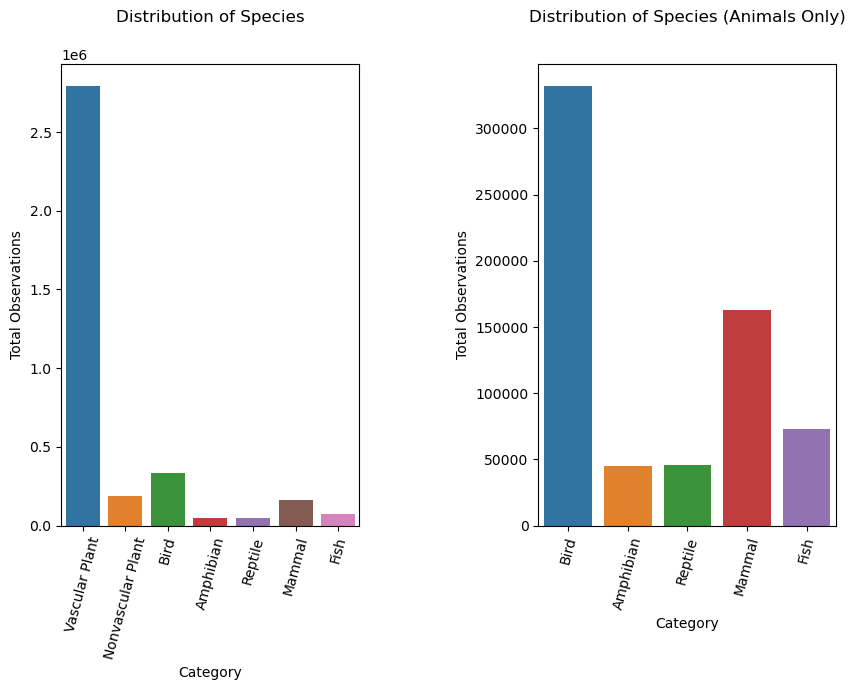

In [15]:
plt.figure(figsize=(10,6))
plt.subplots_adjust(wspace=.6)

plt.subplot(1, 2, 1)
sns.barplot(data= all_df,
            x= 'category',
            y= 'observations',
            hue= 'category',
            estimator= 'sum',
            errorbar= None)

plt.title('Distribution of Species', pad=30)
plt.xlabel('Category')
plt.xticks(rotation= 75)
plt.ylabel('Total Observations')

plt.subplot(1, 2, 2)
sns.barplot(data= all_df[~all_df['category'].isin(['Vascular Plant', 'Nonvascular Plant'])],
            x= 'category',
            y= 'observations',
            hue= 'category',
            estimator= 'sum',
            errorbar= None)

plt.title('Distribution of Species (Animals Only)', pad=30)
plt.xlabel('Category')
plt.xticks(rotation= 75)
plt.ylabel('Total Observations')

plt.show()
plt.close('all')

# Distribution of Conservation Statuses

The vast majority of the species aren't under any conservation status, which is a good sign for the biodiversity.<br>
Now let's have a look at the distribution of species categories amongst those that have a conservation status.<br>
As the table bellow illustrates, we have 6 mammals and 4 birds species listed as `Endangered`, but we've got 3 birds and only 1 mammal listed as `In Recovery`, this could mean birds are recovering faster than mammals.<br> 

In [16]:
conservation_categories = all_df[all_df['conservation_status'] != 'No Status']\
    .groupby(['conservation_status', 'category'])\
    ['scientific_name'].nunique()\
    .unstack()

conservation_categories

category,Amphibian,Bird,Fish,Mammal,Nonvascular Plant,Reptile,Vascular Plant
conservation_status,,,,,,,
Endangered,1.0,4.0,3.0,6.0,NaN,NaN,1.0
In Recovery,NaN,3.0,NaN,1.0,NaN,NaN,NaN
Species of Concern,4.0,68.0,4.0,22.0,5.0,5.0,43.0
Threatened,2.0,NaN,4.0,2.0,NaN,NaN,2.0


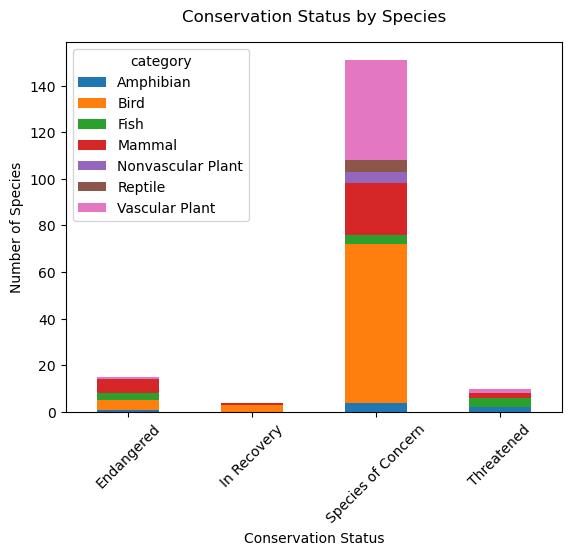

In [17]:
ax = conservation_categories.plot(kind= 'bar', stacked= True)

plt.title('Conservation Status by Species', pad= 15)
plt.xlabel('Conservation Status')
plt.xticks(rotation= 45)
plt.ylabel('Number of Species')

plt.show()
plt.close('all')

## Conservation Effort in Parks
Next let's have a look at the individuals `common names` to have an idea what specimens are the most frequent in the dataset.<br>
For that we'll see what words are the most frequent in the `common names` column.

In [38]:
regex = re.compile('[%s]' % re.escape(string.punctuation))
remove_punctuation = lambda s: regex.sub('', s)

def common_name_word_count(cateogry):
    common_names_lists = species_df[species_df['category'] == category]['common_names']\
        .apply(remove_punctuation)\
        .str\
        .split()\
        .tolist()
    
    # Removing repeated words
    common_names_clean = [list(dict.fromkeys(l)) for l in common_names_lists]
    
    # Aggregating into one list
    common_names_clean = list(chain.from_iterable(i if isinstance(i, list) else [i] for i in common_names_clean))
    
    # Counting words
    word_count = [(w, common_names_clean.count(w)) for w in common_names_clean]
    return pd.DataFrame(set(word_count), columns= ['Word', 'Count']).sort_values('Count', ascending= False)

In [37]:
category = 'Bird'
common_name_word_count(category).head(10)

,Word,Count
100,Warbler,59
103,Sparrow,29
326,American,21
90,Northern,20
213,Owl,18
323,Flycatcher,18
74,Common,18
118,Woodpecker,12
49,Western,12
172,Sandpiper,11


The most frequent `common name` for animals in the `bird` category is `Warbler`.<br>
So let's look at the amount of `Warbler` sighthings accross parks. 

In [42]:
def create_protected_by_parks_df(category, common_name):
    common_name_df = all_df[(all_df['common_names'].str.contains(common_name)) & (all_df['category'] == category)].copy()
    common_name_df['is_protected'] = common_name_df['conservation_status'] != 'No Status'
    
    return common_name_df.groupby(['park_name', 'is_protected'])['observations'].sum().reset_index()

def display_protected_by_parks(protected_by_parks_df):
    plt.figure(figsize=(16,6))
    plt.subplot(1, 1, 1)
    sns.barplot(data= protected_by_parks_df,
                x= 'park_name',
                y= 'observations',
                hue= 'is_protected',
                errorbar= None)
    
    plt.title(F'Status of Protected {common_name} in Parks', pad=30)
    plt.xlabel('Park Name', labelpad=10)
    # plt.xticks(rotation= 30)
    plt.ylabel('Total Observations')
    
    plt.show()
    plt.close('all')

In [45]:
category = 'Bird'
common_name = 'Warbler'
protected_by_parks_df = create_protected_by_parks_df(category, common_name)
protected_by_parks_df

,park_name,is_protected,observations
0,Bryce National Park,False,5565
1,Bryce National Park,True,195
2,Great Smoky Mountains National Park,False,4290
3,Great Smoky Mountains National Park,True,145
4,Yellowstone National Park,False,13995
5,Yellowstone National Park,True,492
6,Yosemite National Park,False,8441
7,Yosemite National Park,True,271


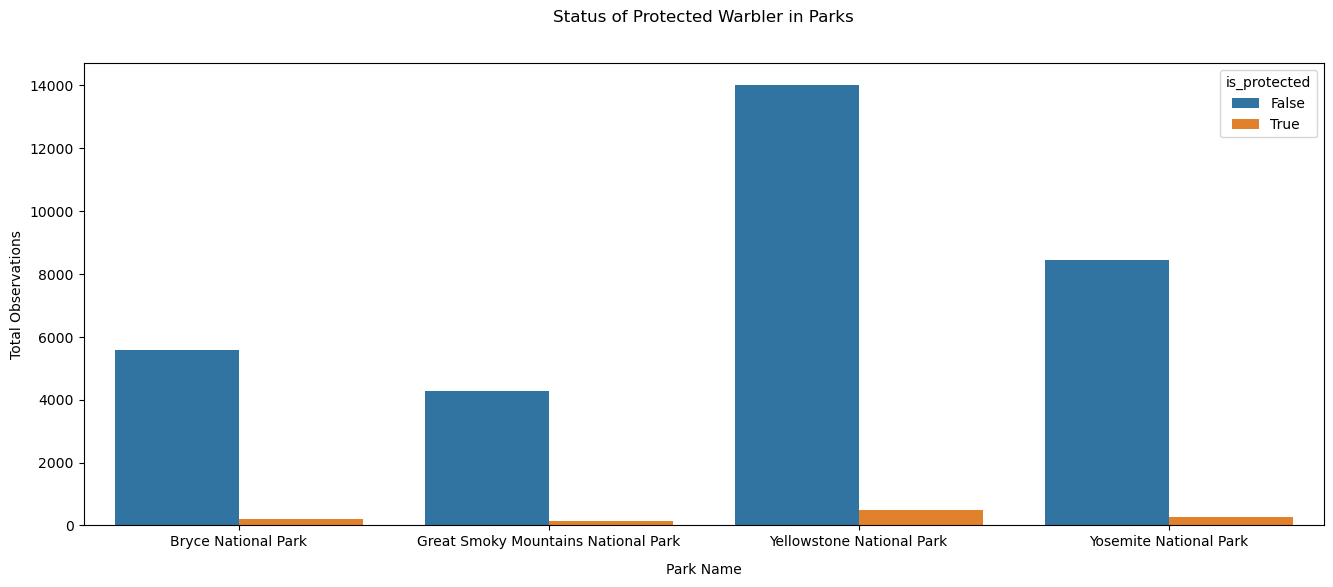

In [44]:
display_protected_by_parks(protected_by_parks_df)

As seen on the graph above, the sighthings of protected species are proportional to the total sighthings.

Next let's have a look at the second most protected animal category, `Mammals`.<br>
As shown in the table bellow, the most frequent `common name` for `Mammal` is `Bat`.<br>
Looking at the total sighthings of `Bats` accross parks we can see that only at the `Great Smoky Mountains National Park` the protected species are spotted less than the non-protected.<br>
This might indicate that conservation efforts could improve in this park.

In [46]:
category = 'Mammal'
common_name_word_count(category).head(10)

,Word,Count
200,Bat,23
80,Shrew,18
9,Myotis,17
185,Mouse,16
13,Chipmunk,13
101,American,12
122,Squirrel,12
189,Eastern,11
175,Vole,11
34,Mountain,10


In [49]:
category = 'Mammal'
common_name = 'Bat'
protected_by_parks_df = create_protected_by_parks_df(category, common_name)
protected_by_parks_df

,park_name,is_protected,observations
0,Bryce National Park,False,1596
1,Bryce National Park,True,1837
2,Great Smoky Mountains National Park,False,1299
3,Great Smoky Mountains National Park,True,1112
4,Yellowstone National Park,False,4044
5,Yellowstone National Park,True,4318
6,Yosemite National Park,False,2345
7,Yosemite National Park,True,2441


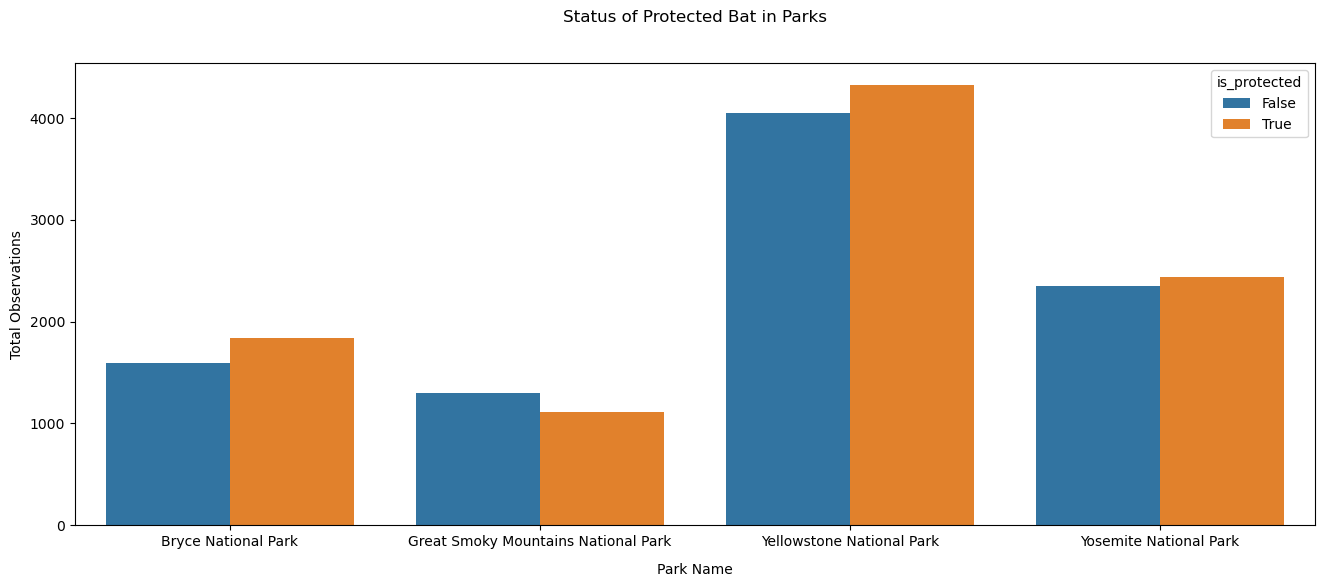

In [50]:
display_protected_by_parks(protected_by_parks_df)

## Conclusion
In this project we were able to create several visualizations to understand the data on species conservation efforts accross several parks.<br>

To answer the questions posed on the beginning of this report:
- What is the distribution of species across parks?
    - The vast majority of the species are plants, and among animal species there's a prevalence of Birds followed by Mammals.
- What is the distribution of conservation statuses across species?
    - Most of the species are not under any conservation status (191 out of the 5824 total species)
- How are conservation efforts among parks?
    - That's heavily dependent on the species, if we look at Warblers the most common bird in the data, the number of sighthings of protected species of Warblers are way smaller than the non-protected species. In contrast, if we look at Bats, the most common mammal in the data, the sighthings of protected species surpasses non-protected in most parks except one.